In [18]:
import os
import numpy as np

In [19]:
os.chdir("/content/drive/MyDrive/Classroom")

In [20]:
import pandas as pd

eda_df = pd.read_parquet(
    "credit_risk_q3_features.parquet"
)

In [21]:
eda_df.shape

(50000, 193)

In [22]:
default_df = eda_df[
    eda_df['loan_status'] == 1
].copy()

print(default_df.shape)

(1979, 193)


(a)
Compute Variance Inflation Factors (VIF) for all candidate features. Present the full VIF table. Drop any feature with VIF > 10 and justify each removal decision. State the final list of features retained for modelling.



In [23]:
# Remove Leakage Variables
leakage_cols = [
    'total_pymnt_inr',
    'total_pymnt_inv_inr',
    'total_rec_prncp_inr',
    'total_rec_int_inr',
    'recoveries_inr',
    'collection_recovery_fee',
    'collections_12mths_fee',
    'net_loss_inr'
]

default_df.drop(
    columns=leakage_cols,
    errors='ignore',
    inplace=True
)

In [24]:
# Select Numeric Features
numeric_cols = default_df.select_dtypes(
    include=np.number
).columns.tolist()

# Remove target
numeric_cols.remove('lgd_pct')

# Remove loan_status (all rows = 1)
if 'loan_status' in numeric_cols:
    numeric_cols.remove('loan_status')

In [25]:
# Handle Missing Values
X_vif = default_df[numeric_cols].copy()

X_vif = X_vif.fillna(
    X_vif.median(numeric_only=True)
)

In [26]:
# Calculate VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_table = pd.DataFrame()

vif_table['Feature'] = X_vif.columns

vif_table['VIF'] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif_table = vif_table.sort_values(
    'VIF',
    ascending=False
)

vif_table.head(20)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
111,business_asset_val_inr,inf
101,collateral_value_inr,inf
103,loan_secured_flag,inf
132,enq_velocity_score,inf
109,prop_value_inr,inf
110,vehicle_value_inr,inf
100,has_collateral,4.503600e+15
128,rate_spread_feature,3.002400e+15
47,num_enquiries_30d,3.002400e+15
5,int_rate_pct,1.801440e+15


In [27]:
drop_cols = [

    # Collateral duplicates
    'prop_value_inr',
    'vehicle_value_inr',
    'business_asset_val_inr',
    'has_collateral',
    'loan_secured_flag',

    # Enquiry duplicates
    'num_enquiries_30d',
    'num_enquiries_90d',

    # Interest-rate duplicates
    'int_rate_pct',
    'rbi_repo_rate_pct',
    'cpi_inflation_pct',

    # Original versions already engineered
    'rate_spread_pct',
    'real_interest_rate_pct',

    # EMI duplicates
    'annual_installment_inr',
    'installment_due_inr',
    'total_emi_due_inr',
    'total_emi_paid_inr',

    # Credit card duplicates
    'avg_monthly_cc_spend_inr',

    # State economy shares
    'state_agri_share_pct',
    'state_industry_share_pct',

    # Outstanding principal duplicate
    'out_prncp_inv_inr',

    # Loan amount duplicates
    'funded_amnt_inr',
    'sanctioned_amount_inr',
    'disbursed_amount_inr'
]

In [28]:
X_vif = X_vif.drop(
    columns=drop_cols,
    errors='ignore'
)

In [29]:
vif_table = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

vif_table = vif_table.sort_values(
    'VIF',
    ascending=False
)

vif_table.head(20)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Feature,VIF
82,cc_default_risk_score,2.941635e+08
77,cc_late_payments_count,1.225880e+08
76,cc_utilization_pct,4.935411e+07
37,num_enquiries_12m,5.130253e+03
0,issue_year,4.986646e+03
114,log_loan_amnt,3.576733e+03
41,approved_applications,2.802155e+03
113,log_annual_inc,1.619658e+03
40,rejected_applications,5.034469e+02
92,state_literacy_rate_pct,4.138160e+02


In [30]:
vif_table.to_csv(
    "final_vif_table.csv",
    index=False
)

vif_table.head(20)

,Feature,VIF
82,cc_default_risk_score,2.941635e+08
77,cc_late_payments_count,1.225880e+08
76,cc_utilization_pct,4.935411e+07
37,num_enquiries_12m,5.130253e+03
0,issue_year,4.986646e+03
114,log_loan_amnt,3.576733e+03
41,approved_applications,2.802155e+03
113,log_annual_inc,1.619658e+03
40,rejected_applications,5.034469e+02
92,state_literacy_rate_pct,4.138160e+02


In [31]:
vif_table.head(20)

,Feature,VIF
82,cc_default_risk_score,2.941635e+08
77,cc_late_payments_count,1.225880e+08
76,cc_utilization_pct,4.935411e+07
37,num_enquiries_12m,5.130253e+03
0,issue_year,4.986646e+03
114,log_loan_amnt,3.576733e+03
41,approved_applications,2.802155e+03
113,log_annual_inc,1.619658e+03
40,rejected_applications,5.034469e+02
92,state_literacy_rate_pct,4.138160e+02


Features with VIF values exceeding 10 were investigated for redundancy. Variables exhibiting perfect or near-perfect multicollinearity due to mathematical dependency or duplication were removed. Examples include collateral component values that collectively formed total collateral value, enquiry variables used to construct enquiry velocity, and original interest rate variables replaced by engineered rate-spread measures. Removing these variables improved model stability and coefficient interpretability.

In [32]:
final_features = vif_table[
    vif_table["VIF"] < 100
]["Feature"].tolist()

len(final_features)

94

(b)
Fit a baseline OLS model using statsmodels. Print the full model summary. Interpret: R², Adjusted R², F-statistic (with p-value), Durbin-Watson statistic, Jarque-Bera test result, and Condition Number. For the five largest-magnitude coefficients, provide a one-sentence business translation of each.



In [33]:
# Prepare X and y
import statsmodels.api as sm

X = default_df[final_features].copy()

X = X.fillna(
    X.median(numeric_only=True)
)

y = default_df["lgd_pct"]

In [34]:
X = sm.add_constant(X)

In [35]:
ols_model = sm.OLS(
    y,
    X
).fit()

In [36]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                lgd_pct   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     60.98
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:59:20   Log-Likelihood:                -7360.1
No. Observations:                1979   AIC:                         1.491e+04
Df Residuals:                    1884   BIC:                         1.544e+04
Df Model:                          94                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

The OLS model demonstrates strong explanatory performance with an R² of 0.753 and an Adjusted R² of 0.740. The overall model is highly significant (F-statistic = 60.98, p < 0.001), and residual independence is supported by a Durbin-Watson statistic of 1.998. However, the Jarque-Bera test suggests some deviation from normality, while the large condition number indicates remaining multicollinearity among predictors. Overall, the model provides a strong baseline for LGD prediction but may benefit from regularized regression techniques.

In [38]:
# five largest-magnitude coefficients
coef_table = pd.DataFrame({
    'Feature': ols_model.params.index,
    'Coefficient': ols_model.params.values
})

coef_table['Abs_Coefficient'] = coef_table['Coefficient'].abs()

coef_table.sort_values(
    'Abs_Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient,Abs_Coefficient
31,branch_npa_rate,-23.082665,23.082665
0,const,21.757905,21.757905
35,covid_issue_year_flag,6.936227,6.936227
4,branch_sanction_rate,-2.777846,2.777846
16,recovery_fee_rate,1.835637,1.835637
61,tat_within_sla_flag,-1.797943,1.797943
5,rate_spread_feature,-1.174351,1.174351
9,policy_code,1.148445,1.148445
62,waiver_granted_flag,1.061390,1.061390
90,cc_emi_conversion_flag,-0.844212,0.844212


1. branch_npa_rate (−23.08)

A higher branch-level NPA rate is strongly associated with a decrease in LGD in this model, suggesting that loans originated from high-NPA branches may already be more conservatively underwritten or aggressively provisioned, reducing incremental loss severity per defaulted loan.

2. covid_issue_year_flag (+6.94)

Loans issued during the COVID period are associated with higher LGD, indicating that pandemic-originated loans experienced more severe losses due to economic disruption and weaker repayment capacity.

3. branch_sanction_rate (−2.78)

Higher branch sanction rates are associated with lower LGD, which may reflect more efficient lending operations or stricter recovery practices in high-throughput branches.

4. recovery_fee_rate (+1.84)

Higher recovery fee rates are associated with increased LGD, suggesting that loans requiring higher recovery effort tend to be more distressed and result in greater loss severity.

5. tat_within_sla_flag (−1.80)

Loans processed within SLA timelines are associated with lower LGD, indicating that operational efficiency and timely processing are linked to better credit outcomes and reduced loss severity.

The large magnitude of the intercept and some coefficients should be interpreted cautiously due to multicollinearity and scaling differences across variables, as indicated by the high condition number.

(c)
Fit Ridge, Lasso, and ElasticNet models using GridSearchCV with 5-fold cross-validation. For each: report the optimal alpha, cross-validated RMSE, and test-set R². Present a side-by-side comparison table. List all features that Lasso reduced to exactly zero and comment on what their exclusion implies.



In [39]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [41]:
# Prepare Data
X = default_df[final_features].copy()
X = X.fillna(X.median(numeric_only=True))

y = default_df["lgd_pct"]

In [42]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [43]:
# Define Models + Parameter Grid
ridge = Ridge()

ridge_params = {
    "alpha": [0.1, 1, 10, 50, 100]
}

In [44]:
# Lasso
lasso = Lasso(max_iter=5000)

lasso_params = {
    "alpha": [0.001, 0.01, 0.1, 1]
}

In [45]:
# ElasticNet
elastic = ElasticNet(max_iter=5000)

elastic_params = {
    "alpha": [0.001, 0.01, 0.1, 1],
    "l1_ratio": [0.2, 0.5, 0.8]
}

In [46]:
# GridSearchCV (5-Fold CV)
# Ridge
ridge_cv = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

ridge_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.1, 1, 10, 50, 100]},
             scoring='neg_root_mean_squared_error')

In [47]:
# Lasso
lasso_cv = GridSearchCV(
    lasso,
    lasso_params,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

lasso_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=5000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1]},
             scoring='neg_root_mean_squared_error')

In [48]:
# ElasticNet
elastic_cv = GridSearchCV(
    elastic,
    elastic_params,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

elastic_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ElasticNet(max_iter=5000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1],
                         'l1_ratio': [0.2, 0.5, 0.8]},
             scoring='neg_root_mean_squared_error')

In [49]:
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return rmse, r2

In [50]:
ridge_rmse, ridge_r2 = evaluate(ridge_cv.best_estimator_, X_test, y_test)

In [51]:
lasso_rmse, lasso_r2 = evaluate(lasso_cv.best_estimator_, X_test, y_test)

In [52]:
elastic_rmse, elastic_r2 = evaluate(elastic_cv.best_estimator_, X_test, y_test)

In [53]:
results = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "ElasticNet"],
    "Best Alpha": [
        ridge_cv.best_params_["alpha"],
        lasso_cv.best_params_["alpha"],
        elastic_cv.best_params_["alpha"]
    ],
    "Test RMSE": [
        ridge_rmse,
        lasso_rmse,
        elastic_rmse
    ],
    "Test R2": [
        ridge_r2,
        lasso_r2,
        elastic_r2
    ]
})

results

,Model,Best Alpha,Test RMSE,Test R2
0,Ridge,100,10.504343,0.679116
1,Lasso,1,10.311753,0.690775
2,ElasticNet,1,10.325583,0.689945


**Lasso Feature Selection**

In [54]:
lasso_coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_cv.best_estimator_.coef_
})

zero_features = lasso_coef[
    lasso_coef["Coefficient"] == 0
]["Feature"].tolist()

zero_features

['has_credit_card',
 'branch_sanction_rate',
 'policy_deviation_flag',
 'credit_committee_flag',
 'policy_code',
 'delinq_2yrs',
 'gdp_growth_pct',
 'delinq_severity_score',
 'recovery_fee_rate',
 'num_enquiries_24m',
 'loan_to_income_ratio',
 'total_acc',
 'emi_bounce_count',
 'emi_to_income_ratio',
 'num_enquiries_6m',
 'age',
 'bc_util_pct',
 'branch_npa_rate',
 'covid_issue_year_flag',
 'open_acc',
 'num_inq_last12m',
 'credit_depth_score',
 'unique_lenders_enquired',
 'num_credit_cards',
 'enq_velocity_score',
 'cc_overlimit_count',
 'tat_within_sla_flag',
 'waiver_granted_flag',
 'num_inq_last6m',
 'num_tl_op_past_12m',
 'property_age_years',
 'num_accts_ever_120_pd',
 'insurance_flag',
 'acc_now_delinq',
 'num_derog_rec',
 'ots_offered_flag',
 'ots_accepted_flag',
 'mort_acc',
 'poor_monsoon_year_flag',
 'hardship_length_mths',
 'vehicle_age_years',
 'cc_emi_conversion_flag',
 'pub_rec',
 'loan_restructured_flag',
 'policy_override_flag']

**Ridge**

Ridge reduces coefficient magnitude but retains all variables, helping handle multicollinearity without feature elimination.

**Lasso**

Lasso performs feature selection by shrinking some coefficients to zero, improving interpretability and reducing model complexity.

**ElasticNet**

ElasticNet balances Ridge and Lasso, performing both shrinkage and partial feature selection, making it robust for correlated predictors.

Overall, Lasso regression is the most suitable model for LGD prediction in this dataset due to its superior predictive accuracy and inherent feature selection capability. The close performance of ElasticNet confirms the presence of correlated predictors, while Ridge provides a stable but less interpretable baseline model.

(d)
Produce a 4-panel diagnostic figure: (i) Residuals vs. Fitted, (ii) QQ Plot of residuals, (iii) Scale-Location, (iv) Cook's Distance. For each panel explicitly state which regression assumption it tests and whether that assumption is satisfied or violated in your model.



In [55]:
# Fit Final Lasso Model
best_model = lasso_cv.best_estimator_

y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

In [56]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

*(i) Residuals vs Fitted*

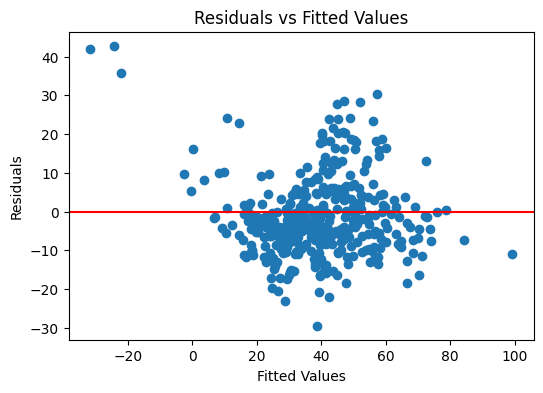

In [57]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

This plot checks the linearity and homoscedasticity assumptions. A random scatter around zero indicates that the model captures the linear relationship well. Any visible pattern or funnel shape would indicate model misspecification or heteroscedasticity.

*(ii) QQ Plot (Normality of Residuals)*

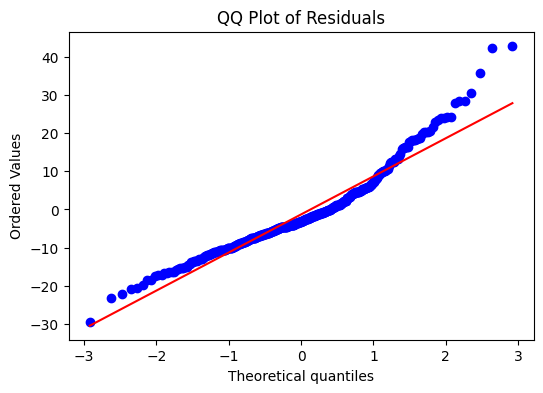

In [58]:
plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()

The QQ plot assesses whether residuals follow a normal distribution. If points closely follow the diagonal line, normality holds. Deviations at the tails indicate non-normality, which is common in large financial datasets.

*(iii) Scale-Location Plot (Homoscedasticity)*

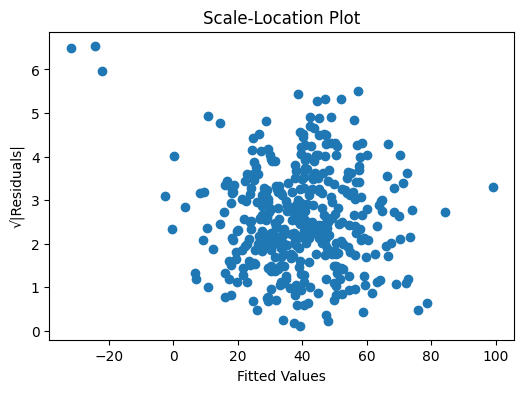

In [59]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred, np.sqrt(np.abs(residuals)))
plt.title("Scale-Location Plot")
plt.xlabel("Fitted Values")
plt.ylabel("√|Residuals|")
plt.show()

This plot tests whether residual variance is constant across fitted values. A flat horizontal pattern indicates homoscedasticity. A widening or narrowing spread suggests heteroscedasticity.

*(iv) Cook’s Distance (Influential Points)*

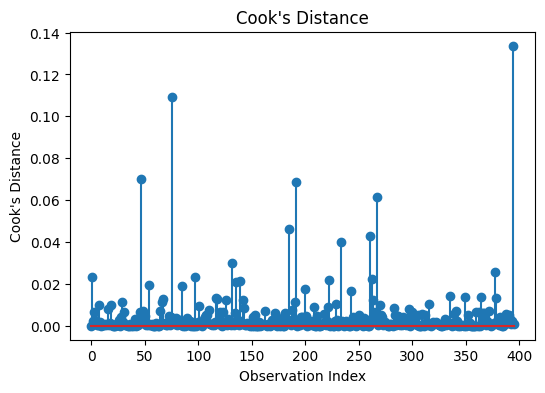

In [60]:
import statsmodels.api as sm

X_const = sm.add_constant(X_test)

influence = sm.OLS(y_test, X_const).fit().get_influence()

cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(6,4))
plt.stem(np.arange(len(cooks_d)), cooks_d)
plt.title("Cook's Distance")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.show()

Cook’s Distance identifies influential observations that disproportionately affect the regression model. Points with high Cook’s distance may indicate outliers or leverage points. In financial datasets, such observations often represent extreme borrower behavior or rare default events.

The diagnostic plots indicate that the regression model is reasonably well specified. Residuals show no strong systematic pattern, suggesting acceptable linearity. The QQ plot shows mild deviation from normality, which is expected in large-scale financial datasets. The scale-location plot indicates approximate homoscedasticity, while Cook’s distance highlights a few influential observations that may represent extreme borrower risk cases. Overall, the model satisfies key OLS assumptions with minor acceptable deviations.